In [2]:
%pip install -q sacrebleu pandas matplotlib

import os, re, time, math, json, random
from collections import Counter
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import sacrebleu

torch.set_num_threads(os.cpu_count())
device = torch.device("cpu")
random.seed(42); torch.manual_seed(42)
print("CPU threads:", torch.get_num_threads())


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: c:\Users\shrey\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
CPU threads: 12


In [3]:
TRAIN_CSV, VAL_CSV, TEST_CSV = "../en_fr_train.csv", "../en_fr_val.csv", "../en_fr_test.csv"

df = pd.read_csv(TRAIN_CSV)
print(df.shape); print(df.columns.tolist()); df.head()

(232825, 2)
['en', 'fr']


,en,fr
0,"Thank you so much, Chris. And it's truly a gre...","Merci beaucoup, Chris. C'est vraiment un honne..."
1,"I have been blown away by this conference, and...",J'ai été très impressionné par cette conférenc...
2,"And I say that sincerely, partly because Put ...","Et je dis çà sincèrement, en autres parce que ..."
3,I flew on Air Force Two for eight years.,J'ai volé avec Air Force 2 pendant huit ans.
4,Now I have to take off my shoes or boots to ge...,"Et maintenant, je dois enlever mes chaussures ..."


In [4]:
# ===== SETTINGS =====
SRC_COL, TGT_COL = df.columns[0], df.columns[1]   # gadbad ho to naam khud likh de
N_TRAIN, N_VAL, N_TEST = 20000, 1000, 1000
MAX_LEN, VOCAB_SIZE = 15, 5000
EMB, HID, BS, EPOCHS, LR = 128, 256, 128, 8, 2e-3
TIME_BUDGET_MIN = 10                              # itne minute baad training ruk jayegi
# ====================

TOK = re.compile(r"\w+|[^\w\s]", re.UNICODE)      # French accents safe
tokenize = lambda t: TOK.findall(str(t).lower())

def load(path, n):
    d = pd.read_csv(path)[[SRC_COL, TGT_COL]].dropna()
    out = []
    for s, t in zip(d[SRC_COL], d[TGT_COL]):
        st, tt = tokenize(s), tokenize(t)
        if 1 <= len(st) <= MAX_LEN and 1 <= len(tt) <= MAX_LEN:
            out.append((st, tt))
    random.shuffle(out)
    return out[:n]

train_data, val_data, test_data = load(TRAIN_CSV, N_TRAIN), load(VAL_CSV, N_VAL), load(TEST_CSV, N_TEST)
print(len(train_data), len(val_data), len(test_data))
print(train_data[0])

20000 275 1000
(['it', 'has', 'two', 'big', 'differences', 'with', 'traditional', 'version', 'control', 'systems', '.'], ['il', 'a', 'deux', 'grandes', 'différences', 'par', 'rapport', 'aux', 'systèmes', 'de', 'contrôle', 'de', 'version', 'traditionnels', '.'])


In [5]:
PAD, SOS, EOS, UNK = 0, 1, 2, 3

def build_vocab(sents, size):
    cnt = Counter(w for s in sents for w in s)
    itos = ["<pad>", "<sos>", "<eos>", "<unk>"] + [w for w, c in cnt.most_common(size - 4) if c >= 2]
    return {w: i for i, w in enumerate(itos)}, itos

src_stoi, src_itos = build_vocab([s for s, _ in train_data], VOCAB_SIZE)
tgt_stoi, tgt_itos = build_vocab([t for _, t in train_data], VOCAB_SIZE)
print("vocab:", len(src_itos), len(tgt_itos))

def encode(ds):
    return [([src_stoi.get(w, UNK) for w in s] + [EOS],
             [SOS] + [tgt_stoi.get(w, UNK) for w in t] + [EOS]) for s, t in ds]

train_enc, val_enc, test_enc = encode(train_data), encode(val_data), encode(test_data)

vocab: 5000 5000


In [8]:
def make_batches(ds, bs, shuffle=True):
    idx = list(range(len(ds)))
    if shuffle: random.shuffle(idx)
    batches = []
    for i in range(0, len(idx), bs * 50):
        c = sorted(idx[i:i + bs * 50], key=lambda j: len(ds[j][0]))
        batches += [c[k:k + bs] for k in range(0, len(c), bs)]
    if shuffle: random.shuffle(batches)
    return batches

def collate(ds, b):
    src = pad_sequence([torch.tensor(ds[j][0]) for j in b], batch_first=True, padding_value=PAD)
    tgt = pad_sequence([torch.tensor(ds[j][1]) for j in b], batch_first=True, padding_value=PAD)
    lens = torch.tensor([len(ds[j][0]) for j in b])
    return src, lens, tgt

In [9]:
class Encoder(nn.Module):
    def __init__(self, v, emb, hid, drop=0.2):
        super().__init__()
        self.emb = nn.Embedding(v, emb, padding_idx=PAD)
        self.lstm = nn.LSTM(emb, hid, batch_first=True)
        self.drop = nn.Dropout(drop)
    def forward(self, src, lens):
        x = pack_padded_sequence(self.drop(self.emb(src)), lens, batch_first=True, enforce_sorted=False)
        _, (h, c) = self.lstm(x)
        return h, c                      # fixed-size context vector

class Decoder(nn.Module):
    def __init__(self, v, emb, hid, drop=0.2):
        super().__init__()
        self.emb = nn.Embedding(v, emb, padding_idx=PAD)
        self.lstm = nn.LSTM(emb, hid, batch_first=True)
        self.fc = nn.Linear(hid, v)
        self.drop = nn.Dropout(drop)
    def forward(self, tok, h, c):
        o, (h, c) = self.lstm(self.drop(self.emb(tok)), (h, c))
        return self.fc(o), h, c

class Seq2Seq(nn.Module):
    def __init__(self, sv, tv):
        super().__init__()
        self.enc, self.dec = Encoder(sv, EMB, HID), Decoder(tv, EMB, HID)
    def forward(self, src, lens, tgt):
        h, c = self.enc(src, lens)
        logits, _, _ = self.dec(tgt[:, :-1], h, c)   # teacher forcing
        return logits

model = Seq2Seq(len(src_itos), len(tgt_itos))
print(f"Params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Params: 3.36M


Epoch 1 | train 4.730 | val 4.051 (ppl 57.4) | 73s
Epoch 2 | train 3.737 | val 3.545 (ppl 34.6) | 58s
Epoch 3 | train 3.309 | val 3.310 (ppl 27.4) | 81s
Epoch 4 | train 3.050 | val 3.219 (ppl 25.0) | 60s
Epoch 5 | train 2.848 | val 3.132 (ppl 22.9) | 59s
Epoch 6 | train 2.685 | val 3.108 (ppl 22.4) | 59s
Epoch 7 | train 2.536 | val 3.086 (ppl 21.9) | 61s
Epoch 8 | train 2.404 | val 3.080 (ppl 21.8) | 59s


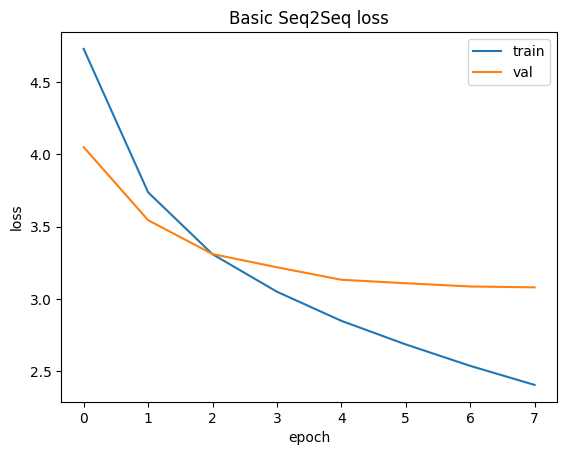

In [10]:
opt = torch.optim.Adam(model.parameters(), lr=LR)
crit = nn.CrossEntropyLoss(ignore_index=PAD)

def run_epoch(ds, train):
    model.train(train); total, n = 0, 0
    for b in make_batches(ds, BS, shuffle=train):
        src, lens, tgt = collate(ds, b)
        with torch.set_grad_enabled(train):
            logits = model(src, lens, tgt)
            loss = crit(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
        if train:
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        total += loss.item(); n += 1
    return total / n

start, best, tr_l, va_l = time.time(), 1e9, [], []
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tl, vl = run_epoch(train_enc, True), run_epoch(val_enc, False)
    tr_l.append(tl); va_l.append(vl)
    if vl < best:
        best = vl; torch.save(model.state_dict(), "best_seq2seq.pt")
    print(f"Epoch {ep} | train {tl:.3f} | val {vl:.3f} (ppl {math.exp(vl):.1f}) | {time.time()-t0:.0f}s")
    if (time.time() - start) / 60 > TIME_BUDGET_MIN:
        print("Time budget khatam, training stop."); break

plt.plot(tr_l, label="train"); plt.plot(va_l, label="val"); plt.legend()
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Basic Seq2Seq loss")
plt.savefig("subtask1_loss.png", dpi=150); plt.show()

In [11]:
model.load_state_dict(torch.load("best_seq2seq.pt")); model.eval()

@torch.no_grad()
def translate_batch(src, lens, max_len=25):
    h, c = model.enc(src, lens)
    tok = torch.full((src.size(0), 1), SOS)
    outs = []
    for _ in range(max_len):
        logits, h, c = model.dec(tok, h, c)
        tok = logits[:, -1].argmax(-1, keepdim=True)
        outs.append(tok)
    res = []
    for seq in torch.cat(outs, 1).tolist():
        w = []
        for i in seq:
            if i == EOS: break
            w.append(tgt_itos[i])
        res.append(w)
    return res

def translate_all(ds):
    preds = [None] * len(ds)
    for b in make_batches(ds, 256, shuffle=False):
        src, lens, _ = collate(ds, b)
        for j, p in zip(b, translate_batch(src, lens)): preds[j] = p
    return preds

test_preds = translate_all(test_enc)
for i in range(5):
    print("SRC :", " ".join(test_data[i][0]))
    print("REF :", " ".join(test_data[i][1]))
    print("PRED:", " ".join(test_preds[i]), "\n")

SRC : but it hadn ' t .
REF : mais non !
PRED: mais ce n ' est pas . 

SRC : i ' m learning not that i am luckier than them , though .
REF : je n ' apprends pas que je suis plus chanceuse qu ' eux ,
PRED: je ne suis pas <unk> , mais je <unk> les <unk> . 

SRC : i had a very normal , low - key kind of upbringing .
REF : j ' ai eu une éducation tout à fait normale et tranquille .
PRED: j ' ai un <unk> de <unk> , un <unk> de <unk> . 

SRC : and now there are 10 , 000 parodies of " friday " on youtube .
REF : et maintenant il y a 10 000 parodies de « vendredi » sur youtube .
PRED: et maintenant , il y a des <unk> <unk> de <unk> <unk> . » 

SRC : i ' m jessi , and this is my suitcase .
REF : je m ' appelle jessi , et voici ma valise .
PRED: je suis <unk> et <unk> , <unk> . 



In [13]:
hyps = [" ".join(p) for p in test_preds]
refs = [" ".join(t) for _, t in test_data]
bleu = sacrebleu.corpus_bleu(hyps, [refs], tokenize="none")
print("Test BLEU:", round(bleu.score, 2)); 
print(bleu)

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Test BLEU: 7.76
BLEU = 7.76 38.1/10.9/5.2/2.5 (BP = 0.903 ratio = 0.907 hyp_len = 8945 ref_len = 9860)


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


len 1-5: n=123 BLEU=10.71
len 6-10: n=508 BLEU=9.23
len 11-15: n=369 BLEU=5.99


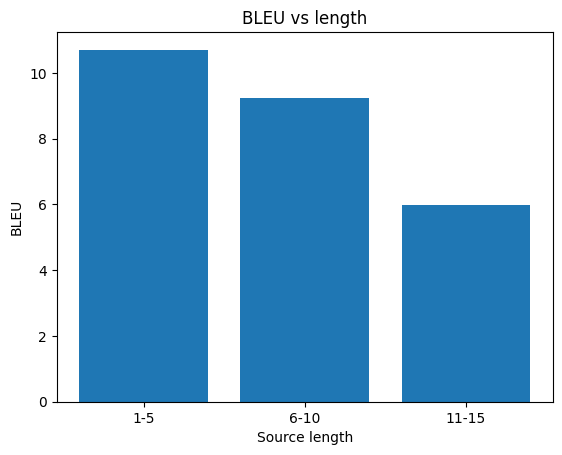


OOV src 6.6% | OOV tgt 8.3% | <unk> in preds 16.4%
Immediate repetition: 12.4%
Avg pred len: 8.9 | Avg ref len: 9.9

--- Long sentence failures ---
SRC : i ' m learning not that i am luckier than them , though .
REF : je n ' apprends pas que je suis plus chanceuse qu ' eux ,
PRED: je ne suis pas <unk> , mais je <unk> les <unk> . 

SRC : i had a very normal , low - key kind of upbringing .
REF : j ' ai eu une éducation tout à fait normale et tranquille .
PRED: j ' ai un <unk> de <unk> , un <unk> de <unk> . 

SRC : and now there are 10 , 000 parodies of " friday " on youtube .
REF : et maintenant il y a 10 000 parodies de « vendredi » sur youtube .
PRED: et maintenant , il y a des <unk> <unk> de <unk> <unk> . » 

SRC : so together with zeit online and open data city , i did this .
REF : donc avec zeit online et open data city , j ' ai fait ça .
PRED: alors , les <unk> <unk> et les <unk> , les gens ont des <unk> . 

SRC : but then i thought , you know , let ' s be honest .
REF : puis j '

In [14]:
## FAilure mode Analysis


# 1) BLEU vs length
bucket_scores = {}
for lo, hi in [(1, 5), (6, 10), (11, 15)]:
    idx = [i for i, (s, _) in enumerate(test_data) if lo <= len(s) <= hi]
    if len(idx) < 10: continue
    sc = sacrebleu.corpus_bleu([hyps[i] for i in idx], [[refs[i] for i in idx]], tokenize="none").score
    bucket_scores[f"{lo}-{hi}"] = sc
    print(f"len {lo}-{hi}: n={len(idx)} BLEU={sc:.2f}")
plt.bar(bucket_scores.keys(), bucket_scores.values())
plt.xlabel("Source length"); plt.ylabel("BLEU"); plt.title("BLEU vs length")
plt.savefig("subtask1_len_bleu.png", dpi=150); plt.show()

# 2) Rare words / UNK
src_oov = np.mean([w not in src_stoi for s, _ in test_data for w in s]) * 100
tgt_oov = np.mean([w not in tgt_stoi for _, t in test_data for w in t]) * 100
pred_unk = np.mean([w == "<unk>" for p in test_preds for w in p]) * 100
print(f"\nOOV src {src_oov:.1f}% | OOV tgt {tgt_oov:.1f}% | <unk> in preds {pred_unk:.1f}%")

# 3) Repetition + length
rep = np.mean([any(p[i] == p[i+1] for i in range(len(p)-1)) for p in test_preds]) * 100
print(f"Immediate repetition: {rep:.1f}%")
print("Avg pred len:", np.mean([len(p) for p in test_preds]).round(1),
      "| Avg ref len:", np.mean([len(t) for _, t in test_data]).round(1))

# 4) Bure examples (lambe sentences)
print("\n--- Long sentence failures ---")
for i in [i for i, (s, _) in enumerate(test_data) if len(s) >= 12][:5]:
    print("SRC :", " ".join(test_data[i][0])); print("REF :", refs[i]); print("PRED:", hyps[i], "\n")

In [15]:
results = {"train_pairs": len(train_enc), "test_pairs": len(test_enc),
           "vocab_src": len(src_itos), "vocab_tgt": len(tgt_itos),
           "bleu": bleu.score, "bleu_by_length": bucket_scores,
           "best_val_loss": best, "epochs_run": len(tr_l)}
json.dump(results, open("subtask1_results.json", "w"), indent=2)
print(results)

{'train_pairs': 20000, 'test_pairs': 1000, 'vocab_src': 5000, 'vocab_tgt': 5000, 'bleu': 7.764214371552442, 'bleu_by_length': {'1-5': 10.706198830599783, '6-10': 9.227135306586886, '11-15': 5.994867776882496}, 'best_val_loss': 3.0797038873036704, 'epochs_run': 8}
